In [509]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [510]:
# Material Parameters
mu = 0.8
jm = 40.0
Identity = torch.eye(3)

In [511]:
# Gent Stress Function
def gent_stress_function(lamda, mu, jm):
    I1 = lamda**2 + 2/lamda
    stress = mu * (lamda - 1/lamda**2) / (1 - (I1 - 3)/jm)
    return stress

In [512]:
def deformation_gradient(lamda):
    diagonal_values = torch.stack([
        lamda,
        lamda**(-0.5),
        lamda**(-0.5)
    ], dim=-1)

    return torch.diag_embed(diagonal_values)

In [513]:
def frobenius_norm(F):
    return torch.sqrt(
        torch.sum((F - Identity)**2, dim=(-2, -1))
    )

In [514]:
def add_noise(P_true_train,eta_min,eta_max,lamda):
    P_char = torch.max(torch.abs(P_true_train))
    noise_sd_min = eta_min * P_char
    noise_sd_max = eta_max * P_char
    F = deformation_gradient(lamda)
    F_lambdamax = deformation_gradient(torch.max(lamda))
    q = 2.0
    t = frobenius_norm(F)
    ksy = torch.randn_like(P_true_train)
    conditional_noise_variance = torch.square(noise_sd_min) + (torch.square(noise_sd_max) - torch.square(noise_sd_min)) * ((t / frobenius_norm(F_lambdamax))**q)
    noise = torch.sqrt(conditional_noise_variance) * ksy
    return noise,conditional_noise_variance

In [515]:
# Synthetic Data Generation
def generate_synthetic_data(num_samples, lamda_min, lamda_max,eta_min,eta_max):
    lamda_train = torch.linspace(lamda_min, lamda_max, num_samples)
    I1_train = lamda_train**2 + 2/lamda_train
    P_true_train = gent_stress_function(lamda_train, mu, jm)   
    noise,conditional_noise_variance = add_noise(P_true_train,eta_min,eta_max,lamda_train)
    Y_train = P_true_train + noise
    Y_train = Y_train.reshape(-1, 1)
    lamda_train =lamda_train.reshape(-1, 1)
    I1_train = I1_train.reshape(-1, 1)
    x = torch.cat((lamda_train, I1_train,Y_train), dim=1)
    return x,conditional_noise_variance


In [516]:
x, conditional_noise_variance = generate_synthetic_data(num_samples=50000, lamda_min=1.0, lamda_max=4.0, eta_min=0.005,eta_max=0.03)

In [517]:
def noise(u):
    return torch.log(u) - torch.log(1-u)

In [518]:
class NeuralNetwork(nn.Module):
    def __init__(self,m = 10):
        super().__init__()
        self.a = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(m))
        self.w = nn.Parameter(torch.randn(m))
        self.b = nn.Parameter(torch.randn(m))

        # Extreme Sparsification:
        self.beta = 2/3

        self.log_alpha_a = nn.Parameter(torch.randn(1))
        self.log_alpha_c = nn.Parameter(torch.randn(m))
        self.log_alpha_w = nn.Parameter(torch.randn(m))
        self.log_alpha_b = nn.Parameter(torch.randn(m))   

        self.gamma = -0.1
        self.zeta = 1.1  

    
    def forward(self,I1):
        u_a = torch.rand_like(self.a)
        u_c = torch.rand_like(self.c)
        u_w = torch.rand_like(self.w)
        u_b = torch.rand_like(self.b)

        eps = 1e-6

        u_a = torch.clamp(u_a, eps, 1-eps)
        u_c = torch.clamp(u_c, eps, 1-eps)
        u_w = torch.clamp(u_w, eps, 1-eps)
        u_b = torch.clamp(u_b, eps, 1-eps)

        s_a = torch.sigmoid((noise(u_a) + (self.log_alpha_a) )/self.beta)
        s_c = torch.sigmoid((noise(u_c) + (self.log_alpha_c) )/self.beta)
        s_w = torch.sigmoid((noise(u_w) + (self.log_alpha_w) )/self.beta)
        s_b = torch.sigmoid((noise(u_b) + (self.log_alpha_b) )/self.beta)

        s_bar_a = s_a*(self.zeta-self.gamma) +  self.gamma
        s_bar_c = s_c*(self.zeta-self.gamma) +  self.gamma
        s_bar_w = s_w*(self.zeta-self.gamma) +  self.gamma
        s_bar_b = s_b*(self.zeta-self.gamma) +  self.gamma
                
        a_mask = torch.clamp(s_bar_a,0,1)
        c_mask = torch.clamp(s_bar_c,0,1)
        w_mask = torch.clamp(s_bar_w,0,1)
        b_mask = torch.clamp(s_bar_b,0,1)

        a = F.softplus(self.a )* a_mask
        c = F.softplus(self.c )* c_mask
        w = F.softplus(self.w )* w_mask
        b = self.b * b_mask
        x = I1 - 3

        z = x * w + b

        # Broadcasting (element wise multiplication)

        hidden = (F.softplus(z) - F.softplus(b))
        psi = (a * x + torch.sum(c * hidden, dim = -1, keepdim = True))
        # sum across the last dimension to get the final output (sum across the columns)
        return psi

In [519]:
def weighted_loss(model,data,noise_variance,gamma,zeta,beta, log_alpha_a, log_alpha_c, log_alpha_w, log_alpha_b):
    lamda = data[:,0].reshape(-1,1)
    I1 = data[:,1].reshape(-1,1)
    Y_train = data[:,2].reshape(-1,1)
    I1.requires_grad_(True)

    rho = 5.0
    prob_a = torch.sigmoid(log_alpha_a - beta * torch.log(torch.tensor(-gamma/zeta)))  
    prob_c = torch.sigmoid(log_alpha_c - beta * torch.log(torch.tensor(-gamma/zeta)))  
    prob_w = torch.sigmoid(log_alpha_w - beta * torch.log(torch.tensor(-gamma/zeta)))  
    prob_b = torch.sigmoid(log_alpha_b - beta * torch.log(torch.tensor(-gamma/zeta)))

    sparsity_penalty = rho * (torch.sum(prob_a) + torch.sum(prob_c) + torch.sum(prob_w) + torch.sum(prob_b))

    P_pred = model(I1)
    # Compute the gradient of the predicted energy potential with respect to I1
    dW_dI1 = torch.autograd.grad(P_pred, I1, grad_outputs=torch.ones_like(P_pred), create_graph=True)[0]
    P_pred = 2 * dW_dI1 * (lamda - 1/lamda**2)

    squared_error= (P_pred - Y_train)**2
    if noise_variance is None:
        loss = torch.mean(squared_error)
    else:
        noise_variance = noise_variance.reshape(-1, 1)
        loss = torch.mean(squared_error / noise_variance)

    loss += sparsity_penalty
    return loss,P_pred

In [520]:
# model = NeuralNetwork(m=32)

In [521]:
print(torch.max(torch.sqrt(conditional_noise_variance)))
print(torch.min(torch.sqrt(conditional_noise_variance)))

tensor(0.1426)
tensor(0.0238)


In [522]:
# def Backpropagation(model, data, noise_variance,gamma,zeta,beta, learning_rate=0.01,num_epochs=1000):

#     #model = NeuralNetwork(m=32)
#     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#     for epoch in range(num_epochs):
#       optimizer.zero_grad()
#       loss,P_pred = weighted_loss(model, data, noise_variance,gamma=gamma, zeta=zeta, beta=beta, log_alpha_a=model.log_alpha_a, log_alpha_c=model.log_alpha_c, log_alpha_w=model.log_alpha_w, log_alpha_b=model.log_alpha_b)
    
#       loss.backward()
#       optimizer.step()
    
#       if epoch % 100 == 0:
#           print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.10f}')  

In [523]:
def Backpropagation(
    model,
    data,
    noise_variance,
    gamma,
    zeta,
    beta,
    learning_rate=0.01,
    num_epochs=10000
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    epoch_history = []
    loss_history = []
    active_history = []

    for epoch in range(num_epochs):

        optimizer.zero_grad()

        loss, P_pred = weighted_loss(
            model,
            data,
            noise_variance,
            gamma=gamma,
            zeta=zeta,
            beta=beta,
            log_alpha_a=model.log_alpha_a,
            log_alpha_c=model.log_alpha_c,
            log_alpha_w=model.log_alpha_w,
            log_alpha_b=model.log_alpha_b
        )

        loss.backward()

        optimizer.step()

        if epoch % 100 == 0:

            active_parameters = expected_active_parameters(
                model
            )

            epoch_history.append(epoch)
            loss_history.append(loss.item())
            active_history.append(active_parameters)

            print(
                f"Epoch [{epoch}/{num_epochs}], "
                f"Loss: {loss.item():.10f}, "
                f"Expected active: {active_parameters:.2f}"
            )

    return epoch_history, loss_history, active_history

In [524]:
# Backpropagation(model, x, noise_variance=conditional_noise_variance,gamma=-0.1, zeta=1.1, beta=2/3, learning_rate=0.01,num_epochs=1000)

In [525]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [526]:
def gent_energy_function(I1, mu, jm):

    psi_true = -(mu * jm / 2) * torch.log(
        1 - (I1 - 3) / jm
    )

    return psi_true

In [527]:
def predict_stress(model, lamda, num_samples=50):

    I1 = lamda**2 + 2/lamda
    I1 = I1.reshape(-1, 1)

    predictions = []

    for _ in range(num_samples):

        I1_sample = I1.clone().detach().requires_grad_(True)

        psi_pred = model(I1_sample)

        dpsi_dI1 = torch.autograd.grad(
            psi_pred,
            I1_sample,
            grad_outputs=torch.ones_like(psi_pred),
            create_graph=False
        )[0]

        P_pred = 2 * dpsi_dI1 * (
            lamda.reshape(-1, 1)
            - 1 / lamda.reshape(-1, 1)**2
        )

        predictions.append(P_pred.detach())

    P_pred_mean = torch.stack(predictions).mean(dim=0)

    return P_pred_mean

In [528]:
model = NeuralNetwork(m=32)

epoch_history, loss_history, active_history = Backpropagation(
    model,
    x,
    conditional_noise_variance,
    gamma=-0.1,
    zeta=1.1,
    beta=2/3,
    learning_rate=0.01,
    num_epochs=10000
)

Epoch [0/10000], Loss: 67261.2187500000, Expected active: 76.05
Epoch [100/10000], Loss: 27437.5507812500, Expected active: 72.21
Epoch [200/10000], Loss: 2113.9951171875, Expected active: 70.39
Epoch [300/10000], Loss: 510.7561035156, Expected active: 69.26
Epoch [400/10000], Loss: 656.4041748047, Expected active: 68.40
Epoch [500/10000], Loss: 6263.5927734375, Expected active: 67.68
Epoch [600/10000], Loss: 914.1448364258, Expected active: 66.93
Epoch [700/10000], Loss: 694.0152587891, Expected active: 66.29
Epoch [800/10000], Loss: 1317.3270263672, Expected active: 65.71
Epoch [900/10000], Loss: 353.7288208008, Expected active: 65.20
Epoch [1000/10000], Loss: 678.5565795898, Expected active: 64.66
Epoch [1100/10000], Loss: 1624.5206298828, Expected active: 64.12
Epoch [1200/10000], Loss: 634.8287353516, Expected active: 63.49
Epoch [1300/10000], Loss: 527.7949829102, Expected active: 62.66
Epoch [1400/10000], Loss: 380.3133239746, Expected active: 61.47
Epoch [1500/10000], Loss: 846

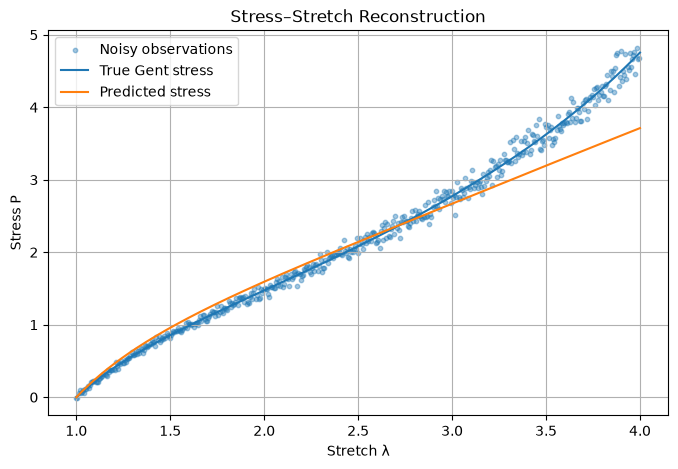

In [529]:
lamda_plot = torch.linspace(1.0, 4.0, 500)

P_true_plot = gent_stress_function(
    lamda_plot,
    mu,
    jm
)

P_pred_plot = predict_stress(
    model,
    lamda_plot,
    num_samples=50
)

lamda_train = x[:, 0]
Y_train = x[:, 2]


plt.figure(figsize=(8, 5))

plt.scatter(
    lamda_train[::100],
    Y_train[::100],
    s=10,
    alpha=0.4,
    label="Noisy observations"
)

plt.plot(
    lamda_plot,
    P_true_plot,
    label="True Gent stress"
)

plt.plot(
    lamda_plot,
    P_pred_plot,
    label="Predicted stress"
)

plt.xlabel("Stretch λ")
plt.ylabel("Stress P")
plt.title("Stress–Stretch Reconstruction")
plt.legend()
plt.grid()

plt.show()

In [530]:
def predict_energy(model, I1, num_gate_samples=50):

    predictions = []

    for _ in range(num_gate_samples):

        psi_pred = model(I1)

        predictions.append(
            psi_pred.detach()
        )

    psi_pred_mean = torch.stack(
        predictions
    ).mean(dim=0)

    return psi_pred_mean

In [531]:
lamda_plot = torch.linspace(1.0, 4.0, 500)

I1_plot = (
    lamda_plot**2
    + 2/lamda_plot
).reshape(-1, 1)

psi_true = gent_energy_function(
    I1_plot,
    mu,
    jm
)

psi_pred = predict_energy(
    model,
    I1_plot,
    num_gate_samples=50
)

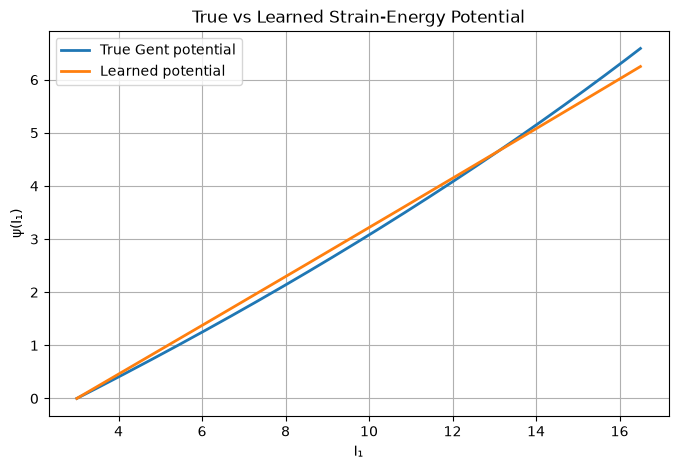

In [532]:
plt.figure(figsize=(8, 5))

plt.plot(
    I1_plot,
    psi_true,
    label="True Gent potential",
    linewidth=2
)

plt.plot(
    I1_plot,
    psi_pred,
    label="Learned potential",
    linewidth=2
)

plt.xlabel("I₁")
plt.ylabel("ψ(I₁)")
plt.title("True vs Learned Strain-Energy Potential")

plt.legend()
plt.grid()

plt.show()

In [533]:
def expected_active_parameters(model):

    constant = torch.log(
        torch.tensor(
            -model.gamma / model.zeta,
            device=model.log_alpha_a.device
        )
    )

    prob_a = torch.sigmoid(
        model.log_alpha_a
        - model.beta * constant
    )

    prob_c = torch.sigmoid(
        model.log_alpha_c
        - model.beta * constant
    )

    prob_w = torch.sigmoid(
        model.log_alpha_w
        - model.beta * constant
    )

    prob_b = torch.sigmoid(
        model.log_alpha_b
        - model.beta * constant
    )

    expected_active = (
        torch.sum(prob_a)
        + torch.sum(prob_c)
        + torch.sum(prob_w)
        + torch.sum(prob_b)
    )

    return expected_active.item()

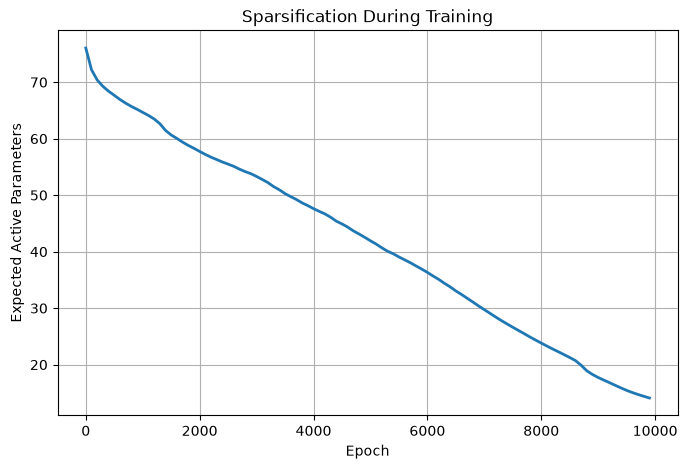

In [534]:
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_history,
    active_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Expected Active Parameters")
plt.title("Sparsification During Training")

plt.grid()
plt.show()